# 12. Adjusted Community Structure Plots (Python)

This notebook reads the saved table outputs from the R analysis notebook
and renders the adjusted PERMANOVA, pairwise mixed-effects, and adjusted-margin figures.


In [53]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Markdown, SVG, display

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import workflow_core as wc

context, base_data, base, advanced = wc.bootstrap_notebook()


## Load Inputs


In [54]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import SVG
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["pdf.fonttype"] = 42

permanova_table = pd.read_csv(
    wc.table_path(context, 29, "adjusted_community_permanova"), sep="\t"
)
pairwise_effects_body = pd.read_csv(
    wc.table_path(context, 30, "pairwise_similarity_mixed_effects"), sep="\t"
)
pairwise_effects_exact = pd.read_csv(
    wc.table_path(
        context, 39, "pairwise_similarity_mixed_effects_exact_location_sensitivity"
    ),
    sep="\t",
)
adjusted_margins_body = pd.read_csv(
    wc.table_path(context, 38, "pairwise_adjusted_margins"), sep="\t"
)
adjusted_margins_exact = pd.read_csv(
    wc.table_path(context, 41, "pairwise_adjusted_margins_exact_location_sensitivity"),
    sep="\t",
)


## Define Plot Helpers


In [ ]:
MODEL_LABELS = {
    "body_region_model": "Body-region model",
    "exact_location_model": "Exact-location model",
}


def save_svg_and_jpg(fig: plt.Figure, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    fig.savefig(output_path.with_suffix(".jpg"), bbox_inches="tight", dpi=300)


def plot_adjusted_permanova(table_df: pd.DataFrame, output_path: Path) -> None:
    plot_df = table_df.loc[~table_df["term"].isin(["Residual", "Total"])].copy()
    plot_df = plot_df.sort_values("r2", ascending=True)
    plot_df["significant"] = plot_df["qvalue"].fillna(1.0) <= 0.1
    colors = plot_df["significant"].map({True: "#b22222", False: "#3b6a8f"}).tolist()

    fig, ax = plt.subplots(figsize=(11, 7.5))
    ax.barh(plot_df["term_label"], plot_df["r2"], color=colors)
    ax.set_xlabel("Marginal R2")
    ax.set_ylabel("")
    ax.set_title("Adjusted PERMANOVA on Bray-Curtis community structure")
    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="s",
            color="none",
            markerfacecolor="#b22222",
            markeredgecolor="#b22222",
            markersize=10,
            label="q <= 0.1",
        ),
        Line2D(
            [0],
            [0],
            marker="s",
            color="none",
            markerfacecolor="#3b6a8f",
            markeredgecolor="#3b6a8f",
            markersize=10,
            label="q > 0.1",
        ),
    ]
    ax.legend(handles=legend_handles, frameon=False, loc="lower right")
    fig.tight_layout()
    save_svg_and_jpg(fig, output_path)
    plt.close(fig)


def plot_pairwise_effects(effects: pd.DataFrame, output_path: Path) -> None:
    if effects.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(
            0.5,
            0.5,
            "No pairwise-effect rows available.",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_axis_off()
        save_svg_and_jpg(fig, output_path)
        plt.close(fig)
        return

    if "effect" in effects.columns:
        effects = effects.loc[effects["effect"] == "fixed"].copy()
    effects["model_label"] = effects["model"].map(MODEL_LABELS).fillna(effects["model"])
    effects["significant"] = effects["qvalue"].fillna(1.0) <= 0.1

    preferred_terms = [
        "Same patient",
        "Same batch date",
        "Same body region",
        "Same exact location",
        "Same chronicity",
        "Same culture positivity",
        "Elapsed-time gap (years)",
        "Mean host fraction",
        "Mean bacterial read depth",
    ]
    observed_terms = effects["term_label"].dropna().unique().tolist()
    ordered_terms = [term for term in preferred_terms if term in observed_terms]
    ordered_terms.extend(
        [term for term in sorted(observed_terms) if term not in ordered_terms]
    )
    y_order = list(reversed(ordered_terms))

    model_order = [
        model
        for model in ["body_region_model", "exact_location_model"]
        if model in effects["model"].unique()
    ]
    if not model_order:
        model_order = sorted(effects["model"].dropna().unique().tolist())
    model_labels = [MODEL_LABELS.get(model, model) for model in model_order]

    fig, axes = plt.subplots(
        1,
        len(model_order),
        figsize=(6.5 * len(model_order), max(5.0, 0.55 * len(y_order))),
        sharey=True,
    )
    if len(model_order) == 1:
        axes = [axes]

    color_map = {True: "#b22222", False: "#3b6a8f"}
    for idx_ax, (ax, model, model_label) in enumerate(zip(axes, model_order, model_labels)):
        sub = effects.loc[effects["model"] == model].copy()
        ax.axvline(0.0, linestyle="--", color="#808080", linewidth=0.8)
        for _, row in sub.iterrows():
            if row["term_label"] not in y_order:
                continue
            y_pos = y_order.index(row["term_label"])
            x = float(row["estimate"])
            low = float(row["conf.low"])
            high = float(row["conf.high"])
            color = color_map[bool(row["significant"])]
            ax.errorbar(
                x=x,
                y=y_pos,
                xerr=[[x - low], [high - x]],
                fmt="o",
                color=color,
                ecolor=color,
                elinewidth=1.0,
                capsize=3,
                markersize=6,
            )

        # ax.set_title(model_label)
        ax.set_xlabel("Coefficient on Bray-Curtis distance")
        ax.set_yticks(np.arange(len(y_order)))
        ax.set_yticklabels(y_order)
        if idx_ax == 0:
            ax.set_ylabel("")
        if idx_ax == len(model_order) - 1:
            legend_handles = [
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="none",
                    markerfacecolor="#b22222",
                    markeredgecolor="#b22222",
                    label="q <= 0.1",
                ),
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="none",
                    markerfacecolor="#3b6a8f",
                    markeredgecolor="#3b6a8f",
                    label="q > 0.1",
                ),
            ]
            ax.legend(
                handles=legend_handles,
                frameon=False,
                # loc="upper left",
                # bbox_to_anchor=(1, 1.02),
            )
    # fig.suptitle("Pairwise mixed models for Bray-Curtis distance", y=1.06)
    fig.tight_layout()
    save_svg_and_jpg(fig, output_path)
    plt.close(fig)




In [69]:
def plot_adjusted_margins(
    margins: pd.DataFrame,
    output_path: Path,
    panel_size: tuple[float | int, float | int] = (4.2, 4.8),
    sharey: bool = False,
    term_order: list[str] | None = None,
) -> None:
    """Plot adjusted predicted Bray-Curtis distances by term in a single-row layout.

    Args:
        margins: DataFrame containing term labels, sharing level, estimated means,
            and confidence interval columns.
        output_path: Base path used by `save_svg_and_jpg`.
    """
    if margins.empty:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.text(
            0.5,
            0.5,
            "No adjusted-margin rows available.",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        ax.set_axis_off()
        save_svg_and_jpg(fig, output_path)
        plt.close(fig)
        return

    # preferred_terms = [
    #     "Same patient",
    #     "Same chronicity",
    #     "Same body region",
    #     "Same exact location",
    # ]
    # observed_terms = margins["term_label"].dropna().unique().tolist()
    # term_order = [term for term in preferred_terms if term in observed_terms]
    # term_order.extend(
    #     [term for term in sorted(observed_terms) if term not in term_order]
    # )
    if term_order is None:
        term_order = margins["term_label"].dropna().unique().tolist()

    ncols = max(1, len(term_order))
    fig, axes = plt.subplots(
        1,
        ncols,
        figsize=(max(panel_size[0] * ncols, 6.0), panel_size[1]),
        squeeze=False,
        sharey=sharey,
    )
    axes_flat = [ax for row in axes for ax in row]

    level_order = ["Not shared", "Shared"]
    level_colors = {"Not shared": "#6c757d", "Shared": "#b22222"}
    x_map = {level: idx for idx, level in enumerate(level_order)}

    for idx_ax, (ax, term) in enumerate(zip(axes_flat, term_order)):
        sub = margins.loc[margins["term_label"] == term].copy()
        if sub.empty:
            ax.set_axis_off()
            continue

        sub["level"] = pd.Categorical(
            sub["level"], categories=level_order, ordered=True
        )
        sub = sub.sort_values("level")

        xs: list[float] = []
        ys: list[float] = []

        for _, row in sub.iterrows():
            level = row["level"]
            if pd.isna(level):
                continue

            x = x_map[str(level)]
            y = float(row["emmean"])
            low = float(row["conf.low"])
            high = float(row["conf.high"])

            ax.errorbar(
                x=x,
                y=y,
                yerr=[[y - low], [high - y]],
                fmt="o",
                color=level_colors[str(level)],
                ecolor=level_colors[str(level)],
                elinewidth=1.2,
                capsize=3,
                markersize=7,
            )
            xs.append(x)
            ys.append(y)

        # Expand x-limits slightly to accommodate error bars
        ax.set_xlim(-0.5, len(level_order) - 0.5)

        if len(xs) >= 2:
            ax.plot(xs, ys, color="#a0a0a0", linewidth=0.9)

        ax.set_title(term)
        ax.set_xticks([x_map[level] for level in level_order])
        ax.set_xticklabels(level_order, rotation=20, ha="right")
        ax.set_xlabel("")
        if idx_ax == 0:
            ax.set_ylabel("Adjusted Bray-Curtis distance")

        if idx_ax == len(term_order) - 1:
            legend_handles = [
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="none",
                    markerfacecolor=level_colors["Not shared"],
                    markeredgecolor=level_colors["Not shared"],
                    label="Not shared",
                ),
                Line2D(
                    [0],
                    [0],
                    marker="o",
                    color="none",
                    markerfacecolor=level_colors["Shared"],
                    markeredgecolor=level_colors["Shared"],
                    label="Shared",
                ),
            ]
            # Add legend to the last subplot
            ax.legend(
                handles=legend_handles,
                frameon=False,
                loc="upper left",
                # ncol=2,
                bbox_to_anchor=(1.05, 1.0),
            )
    # fig.suptitle(
    #     "Adjusted predicted Bray-Curtis distance from pairwise mixed models\n"
    #     "Other pairwise indicators held at 0; technical covariates fixed at cohort means",
    #     y=1.08,
    # )
    fig.tight_layout()
    save_svg_and_jpg(fig, output_path)
    plt.close(fig)

## Render Figure 12 Panels


In [70]:
adjusted_margins_body

,model,focal_term,term_label,level,emmean,std.error,conf.low,conf.high,held_same_batch,held_same_culture_positive,held_elapsed_time_gap,held_mean_host_fraction,held_mean_log10_bacterial_reads
0,body_region_model,same_patient,Patient,Not shared,0.801121,0.026781,0.748353,0.853889,0,0,0.700728,0.683148,5.574669
1,body_region_model,same_patient,Patient,Shared,0.740420,0.034872,0.671918,0.808922,0,0,0.700728,0.683148,5.574669
2,body_region_model,same_chronicity,Chronicity,Not shared,0.801121,0.026781,0.748353,0.853889,0,0,0.700728,0.683148,5.574669
3,body_region_model,same_chronicity,Chronicity,Shared,0.731968,0.027578,0.677667,0.786268,0,0,0.700728,0.683148,5.574669
4,body_region_model,same_body_region,Body region,Not shared,0.801121,0.026781,0.748353,0.853889,0,0,0.700728,0.683148,5.574669
5,body_region_model,same_body_region,Body region,Shared,0.778097,0.028108,0.722766,0.833428,0,0,0.700728,0.683148,5.574669


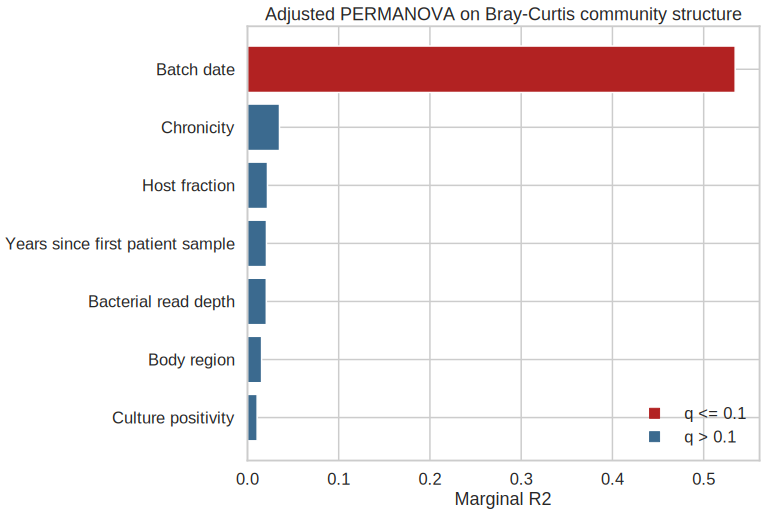

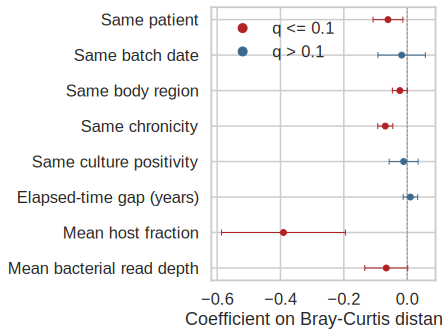

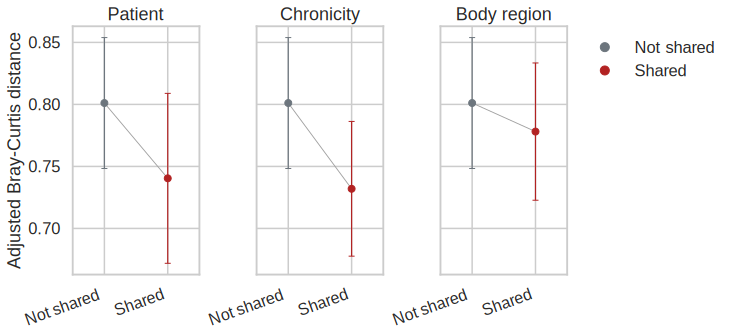

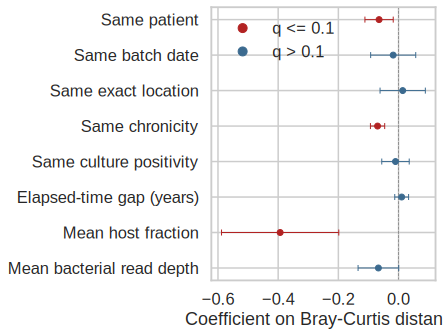

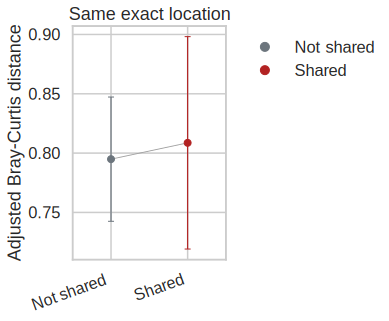

In [71]:
fig_12_01 = wc.figure_path(context, 12, "adjusted_permanova")
plot_adjusted_permanova(permanova_table, fig_12_01)

body_effects = pairwise_effects_body.copy()
body_effects["model"] = "body_region_model"
fig_12_02 = wc.figure_path(context, 13, "pairwise_similarity_mixed")
plot_pairwise_effects(body_effects, fig_12_02)

adjusted_margins_body["term_label"] = adjusted_margins_body["term_label"].map(
    lambda x: x.replace("Same ", "").capitalize()
)
fig_12_03 = wc.figure_path(context, 22, "pairwise_adjusted_margins")
plot_adjusted_margins(adjusted_margins_body, fig_12_03, sharey=True, panel_size=(3.5, 5))

exact_effects = pairwise_effects_exact.copy()
exact_effects["model"] = "exact_location_model"
fig_12_04 = wc.figure_path(
    context, 23, "pairwise_similarity_mixed_exact_location_sensitivity"
)
plot_pairwise_effects(exact_effects, fig_12_04)

fig_12_05 = wc.figure_path(
    context, 24, "pairwise_adjusted_margins_exact_location_sensitivity"
)
plot_adjusted_margins(adjusted_margins_exact, fig_12_05)

display(SVG(filename=str(fig_12_01)))
display(SVG(filename=str(fig_12_02)))
display(SVG(filename=str(fig_12_03)))
display(SVG(filename=str(fig_12_04)))
display(SVG(filename=str(fig_12_05)))
